# Tutorial for the nonregression test base
This notebook contains the set of test cases used as nonregression test base for pyHarm. It contains 5 examples treating different case of problem using pyHarm. An initial action from the user is required by providing the right path to the source code if pyHarm is not installed with the right version. The presentation of the set of test case is provided in the Technical Note NT_011856

## pyHarm requirements : 
The notebook has been created under the commit *80b02569*, please provide a version of pyHarm that is newer or equal to this commit.

In [1]:
print("Kernel is launched if this print is showed")

Kernel is launched if this print is showed


In [2]:
import os
import sys

PATH_TO_PYHARM = False
PATH_TO_PYHARM = os.getcwd() + "/.."
if PATH_TO_PYHARM != False:
    sys.path.append(PATH_TO_PYHARM)
# ------------------ IMPORTS ------------------ #
import copy
import json

import matplotlib.pyplot as plt
import numpy as np
import scipy.io

import pyHarm

# ------------------ MATPLOTLIB DEFAULT STYLE ------------------ #
plt.style.use("default")
FONT_BASE = 25
width_fig = 15
ratio_fig = (width_fig, 1 / (16 / 10.0) * width_fig)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
plt.rc("xtick", labelsize=FONT_BASE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=FONT_BASE)  # fontsize of the tick labels
plt.rc("legend", fontsize=FONT_BASE)  # legend fontsize
plt.rc("axes", labelsize=FONT_BASE)
plt.rc("axes", titlesize=FONT_BASE + 5)  # fontsize of the title

style_plots_ref = {
    "frf_lin": {
        "linestyle": "dashed",
        "color": np.array([0, 0, 0]),
        "label": "Linear solution",
    },
    "frf_nl": {
        "linestyle": "solid",
        "linewidth": 2,
        "color": np.array([255, 140, 0]) / 255.0,
        "marker": ".",
        "label": "nonlinear solution",
    },
}

# First test case : Duffing Oscillators
## Simple Duffing
The first test case shows the capability of pyHarm to handle correctly bifurcations and more importantly turning points. It uses a cubic spring type of non linear element.

In [3]:
# ------------------ SYSTEM CONSTRUCTION ------------------ #
MassMatrix = np.array([[1]])
DampMatrix = 1e-1 * np.array([[1]])
RigidMatrix = np.array([[1]])
LinSys = dict()
LinSys["M"] = MassMatrix
LinSys["C"] = DampMatrix
LinSys["K"] = RigidMatrix
LinSys["G"] = 0 * MassMatrix


# ------------------ INPUT CONSTRUCTION ------------------ #
INP = {
    "analysis": {
        "FRF": {
            "study": "frf",
            "puls_inf": 0.1,
            "puls_sup": 7.0,
            "ds0": 5e-2,
            "ds_min": 1e-12,
            "ds_max": 5e-2,
            "sign_ds": 1,
            "verbose": True,
            "stepsizer": "acceptance",
            "predictor": "tangent",
            "predictor_options": {"verbose": True},
            "corrector": "arc_length",
            "preconditioner": "nopreconditioner",
            "stopper": "bounds",
            "solver": "scipyroot",
        }
    },
    "system": {
        "type": "Base",
        "nh": 7,
        "nti": 1024,
        "adim": {"status": False, "lc": 1.0, "wc": 1.0},
    },
    "substructures": {"sub1": {"matrix": LinSys, "ndofs": 1}},
    "connectors": {
        "loading": {
            "type": "CosinusForcing",
            "connect": {"sub1": [0]},
            "dirs": [0],
            "amp": 1e0,
        },
        "cubic": {
            "type": "CubicSpring",
            "connect": {"sub1": [0]},
            "dirs": [0],
            "k": 1e0,
        },
    },
}

# ------------------ PYHARM MAESTRO CONSTRUCTION ------------------ #

NRB_SD = pyHarm.Maestro(INP)
NRB_SD.operate()

solution converged at om=0.1
solution converged at om=0.1479508448047943
solution converged at om=0.17651887728430185
solution converged at om=0.18372584451209975
solution converged at om=0.1879293030393937
solution converged at om=0.19491550895907064
solution converged at om=0.2182425446118936
solution converged at om=0.24403924423798562
solution converged at om=0.25562208073811593
solution converged at om=0.26138672790941125
solution converged at om=0.2647993162606292
solution converged at om=0.2671530644201622
solution converged at om=0.2690841193118749
solution converged at om=0.2710279361421444
solution converged at om=0.27342301989658463
solution converged at om=0.2768493520572894
solution converged at om=0.2822125545298479
solution converged at om=0.2915243886052985
solution converged at om=0.3104525666353639
solution converged at om=0.3416767824296192
solution converged at om=0.3715419250553975
solution converged at om=0.39424410740340005
solution converged at om=0.410633052176

solution converged at om=2.4792979063180853
solution converged at om=2.459545487818944
solution converged at om=2.4394915043583407
solution converged at om=2.4191434033000716
solution converged at om=2.3985093592755504
solution converged at om=2.377598322105801
solution converged at om=2.356420067359607
solution converged at om=2.334985249841184
solution converged at om=2.3133054603777787
solution converged at om=2.2913932863724673
solution converged at om=2.269262376704705
solution converged at om=2.246927511704272
solution converged at om=2.224404679097451
solution converged at om=2.2017111570346657
solution converged at om=2.1788656055616142
solution converged at om=2.1558881682003763
solution converged at om=2.1328005856724714
solution converged at om=2.1096263242348243
solution converged at om=2.0863907216269437
solution converged at om=2.0631211542615073
solution converged at om=2.039847230055254
solution converged at om=2.0166010122196036
solution converged at om=1.9934172804480

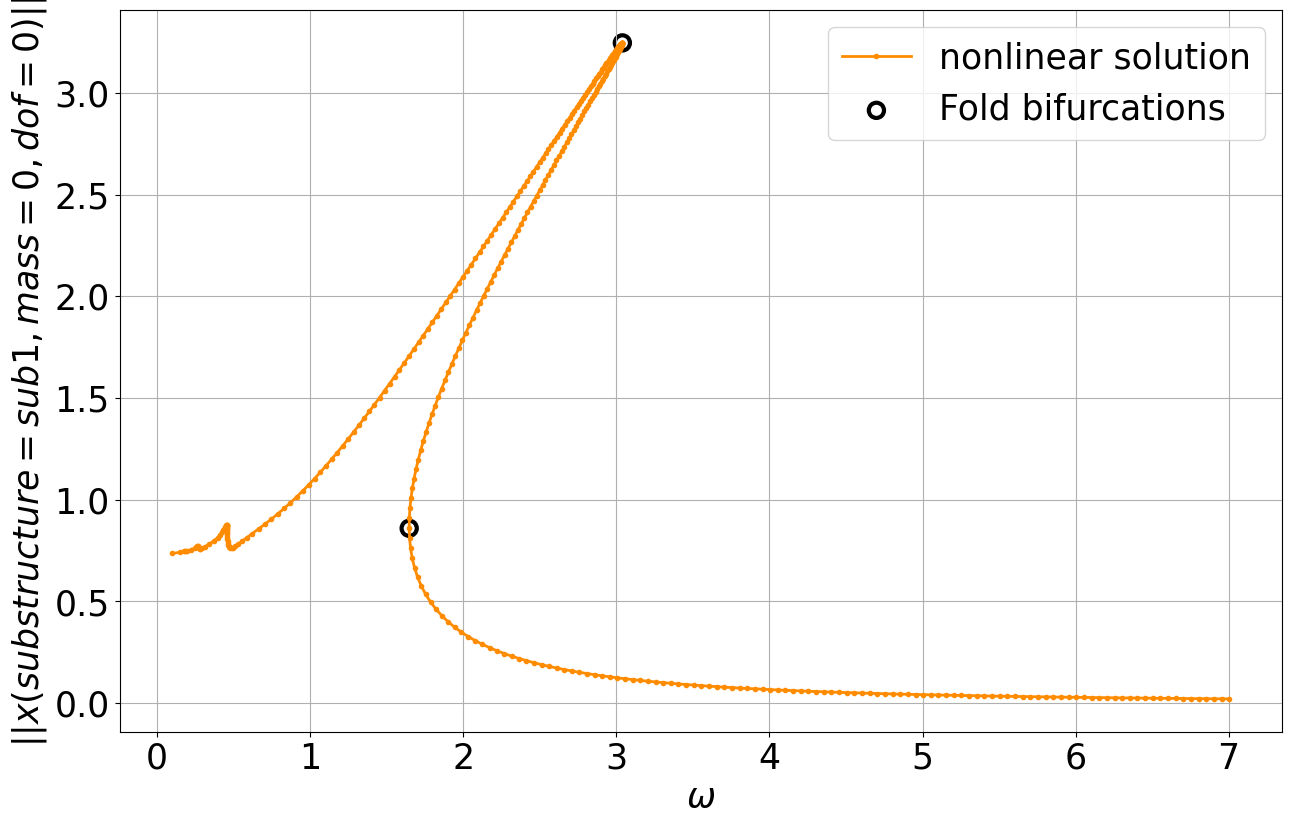

In [4]:
indices_selection = ("sub1", 0, 0)
indexH = NRB_SD.getIndex(*indices_selection)
SA = [sol for sol in NRB_SD.nls["FRF"].SolList if sol.flag_accepted]
om = np.array([sol.x[-1] for sol in SA])
ampH = np.array([np.linalg.norm(sol.x[indexH]) for sol in SA])

SA_bifurc = [
    sol for sol in NRB_SD.nls["FRF"].SolList if (sol.flag_accepted and sol.flag_bifurcation)
]
om_bifurc = np.array([sol.x[-1] for sol in SA_bifurc])
ampH_bifurc = np.array([np.linalg.norm(sol.x[indexH]) for sol in SA_bifurc])

fig, ax = plt.subplots(figsize=ratio_fig)
ax.plot(om, ampH, **style_plots_ref["frf_nl"])
ax.scatter(
    om_bifurc,
    ampH_bifurc,
    s=120,
    marker="o",
    color="k",
    facecolors="none",
    linewidth=3,
    label="Fold bifurcations",
)
ax.set_xlabel("$\\omega$")
ax.set_ylabel("$\|\|x(substructure={},mass={},dof={})\|\|$".format(*indices_selection))
ax.legend()
ax.grid()

## Coupled Duffing

In [5]:
# ------------------ SYSTEM CONSTRUCTION ------------------ #
MassMatrix = np.array([[1]])
DampMatrix = 1e-1 * np.array([[1]])
RigidMatrix = np.array([[1]])
LinSys = dict()
LinSys["M"] = MassMatrix
LinSys["C"] = DampMatrix
LinSys["K"] = RigidMatrix
LinSys["G"] = 0 * MassMatrix

# ------------------ INPUT CONSTRUCTION ------------------ #
INP = {
    "analysis": {
        "FRF": {
            "study": "frf",
            "puls_inf": 0.1,
            "puls_sup": 7.0,
            "ds0": 5e-2,
            "ds_min": 1e-12,
            "ds_max": 5e-2,
            "sign_ds": 1,
            "verbose": True,
            "stepsizer": "acceptance",
            "predictor": "tangent",
            "predictor_options": {"verbose": True},
            "corrector": "arc_length",
            "preconditioner": "nopreconditioner",
            "stopper": "bounds",
            "solver": "scipyroot",
        }
    },
    "system": {
        "type": "Base",
        "nh": 7,
        "nti": 1024,
        "adim": {"status": False, "lc": 1.0, "wc": 1.0},
    },
    "substructures": {
        "sub1": {"matrix": LinSys, "ndofs": 1},
        "sub2": {"matrix": LinSys, "ndofs": 1},
    },
    "connectors": {
        "loading": {
            "type": "CosinusForcing",
            "connect": {"sub1": [0]},
            "dirs": [0],
            "amp": 2e0,
        },
        "cubic1": {
            "type": "CubicSpring",
            "connect": {"sub1": [0]},
            "dirs": [0],
            "k": 1e0,
        },
        "cubic2": {
            "type": "CubicSpring",
            "connect": {"sub2": [0]},
            "dirs": [0],
            "k": 1e0,
        },
        "LinearSpring": {
            "type": "LinearSpring",
            "connect": {"sub1": [0], "sub2": [0]},
            "dirs": [0],
            "k": 5e0,
        },
    },
}

# ------------------ PYHARM MAESTRO CONSTRUCTION ------------------ #
NRB_CD = pyHarm.Maestro(INP)
NRB_CD.operate()

solution converged at om=0.1
solution converged at om=0.1462385188699392
solution converged at om=0.1725229144262887
solution converged at om=0.1803639850595797
solution converged at om=0.18408273433341657
solution converged at om=0.18686882147116102
solution converged at om=0.19023096659034447
solution converged at om=0.19642043406715987
solution converged at om=0.21296144777789217
solution converged at om=0.23590156096935652
solution converged at om=0.24860151331689478
solution converged at om=0.25554150874113907
solution converged at om=0.2598189699816765
solution converged at om=0.26270811936336824
solution converged at om=0.26481102188320005
solution converged at om=0.2664588392972974
solution converged at om=0.26786087538843767
solution converged at om=0.2691718203435423
solution converged at om=0.2705293711566235
solution converged at om=0.27208063108551034
solution converged at om=0.27400408974143775
solution converged at om=0.2765314662163591
solution converged at om=0.2799905

solution converged at om=2.7391737359418666
solution converged at om=2.749552823951885
solution converged at om=2.7597339325014185
solution converged at om=2.7697181410814875
solution converged at om=2.779506516144902
solution converged at om=2.789100110240517
solution converged at om=2.7984999612138584
solution converged at om=2.8077070914712703
solution converged at om=2.8167225073041258
solution converged at om=2.82554719826882
solution converged at om=2.8341821366198654
solution converged at om=2.842628276793097
solution converged at om=2.8508865549348603
solution converged at om=2.85895788847527
solution converged at om=2.8668431757424373
solution converged at om=2.8745432956140062
solution converged at om=2.88205910720513
solution converged at om=2.8893914495889517
solution converged at om=2.8965411415477416
solution converged at om=2.9035089813528914
solution converged at om=2.9102957465709283
solution converged at om=2.9169021938939954
solution converged at om=2.92332905899299


solution converged at om=1.6570869574944969
solution converged at om=1.6618779710119582
solution converged at om=1.6688115339828815
solution converged at om=1.6780427793555457
solution converged at om=1.6897217317628603
solution converged at om=1.7039858635746237
solution converged at om=1.7209509035113375
solution converged at om=1.7407004805088406
solution converged at om=1.763275783768245
solution converged at om=1.7886669742485388
solution converged at om=1.8168083067288248
solution converged at om=1.84757853881252
solution converged at om=1.8808071575907341
solution converged at om=1.916285552878525
solution converged at om=1.9537810756095506
solution converged at om=1.9930514351399933
solution converged at om=2.0338572244590556
solution converged at om=2.0759712314123124
solution converged at om=2.119184152896332
solution converged at om=2.1633070441776723
solution converged at om=2.20817119303955
solution converged at om=2.253626163962743
solution converged at om=2.2995366320632

solution converged at om=4.363417979872311
solution converged at om=4.366785974996031
solution converged at om=4.369761398874317
solution converged at om=4.37234762820828
solution converged at om=4.374547702446727
solution converged at om=4.376364351284695
solution converged at om=4.377800019089059
solution converged at om=4.378856886691332
solution converged at om=4.379536890940116
solution converged at om=4.3798417423610765
solution converged at om=4.3797729412374755
Alerte: un point limite (fold) a été détecté --> changement de sens de parcours
solution converged at om=4.3793317923942015
solution converged at om=4.378519418946356
solution converged at om=4.377336775256711
solution converged at om=4.3757846593367065
solution converged at om=4.373863724921519
solution converged at om=4.37157449345242
solution converged at om=4.368917366208377
solution converged at om=4.365892636845141
solution converged at om=4.362500504623513
solution converged at om=4.3587410886422235
solution conve

solution converged at om=6.875373346046686
solution converged at om=6.925366033634929
solution converged at om=6.975359119943011
solution converged at om=7.025352578763783
Wall clock time: 5.2378010749816895


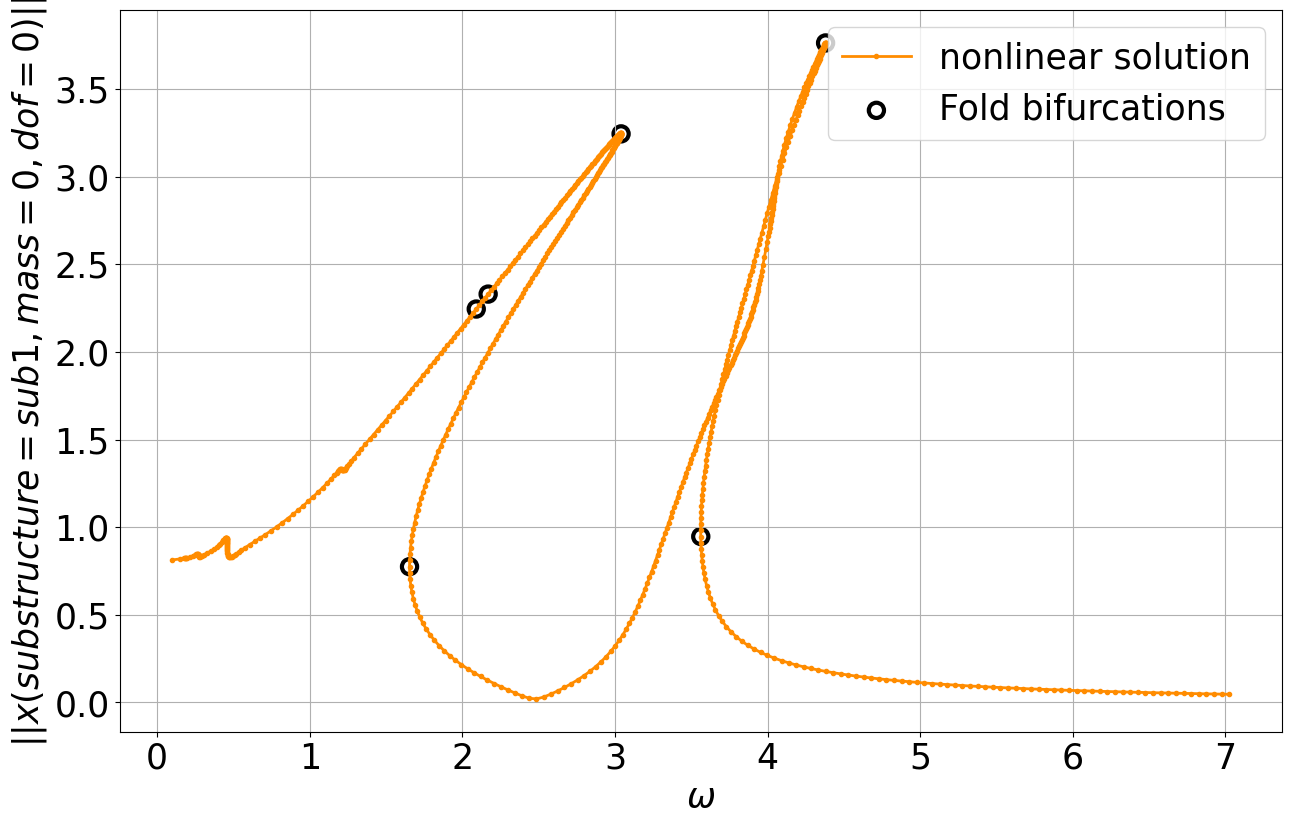

In [6]:
indices_selection = ("sub1", 0, 0)
indexH = NRB_CD.getIndex(*indices_selection)
SA = [sol for sol in NRB_CD.nls["FRF"].SolList if sol.flag_accepted]
om = np.array([sol.x[-1] for sol in SA])
ampH = np.array([np.linalg.norm(sol.x[indexH]) for sol in SA])

SA_bifurc = [
    sol for sol in NRB_CD.nls["FRF"].SolList if (sol.flag_accepted and sol.flag_bifurcation)
]
om_bifurc = np.array([sol.x[-1] for sol in SA_bifurc])
ampH_bifurc = np.array([np.linalg.norm(sol.x[indexH]) for sol in SA_bifurc])

fig, ax = plt.subplots(figsize=ratio_fig)
ax.plot(om, ampH, **style_plots_ref["frf_nl"])
ax.scatter(
    om_bifurc,
    ampH_bifurc,
    s=120,
    marker="o",
    color="k",
    facecolors="none",
    linewidth=3,
    label="Fold bifurcations",
)
ax.set_xlabel("$\\omega$")
ax.set_ylabel("$\|\|x(substructure={},mass={},dof={})\|\|$".format(*indices_selection))
ax.legend()
ax.grid()

# Second test case : Jenkins

In [7]:
# ------------------ SYSTEM CONSTRUCTION ------------------ #
MassMatrix = np.array([[1, 0], [0, 2e-02]])
DampMatrix = 5e-2 * np.array([[2, -1], [-1, 1]])
RigidMatrix = np.array([[680, -40], [-40, 40]])
LinSys = dict()
LinSys["M"] = MassMatrix
LinSys["C"] = DampMatrix
LinSys["K"] = RigidMatrix
LinSys["G"] = 0 * MassMatrix


# ------------------ INPUT CONSTRUCTION ------------------ #
INP = {
    "analysis": {
        "FRF": {
            "study": "frf",
            "puls_inf": 24.0,
            "puls_sup": 28.0,
            "ds0": 3e-2,
            "ds_min": 1e-12,
            "ds_max": 3e-2,
            "sign_ds": 1,
            "verbose": True,
            "stepsizer": "acceptance",
            "predictor": "secant",
            "predictor_options": {"bifurcation_detect": False},
            "corrector": "pseudo_arc_length",
            "preconditioner": "nopreconditioner",
            "stopper": "bounds",
            "solver": "scipyroot",
        },
    },
    "system": {
        "type": "Base",
        "nh": 7,
        "nti": 1024,
        "adim": {"status": False, "lc": 1.0, "wc": 1.0},
    },
    "substructures": {"sub1": {"matrix": LinSys, "ndofs": 1}},
    "connectors": {
        "loading": {
            "type": "CosinusForcing",
            "connect": {"sub1": [0]},
            "dirs": [0],
            "amp": 1e0,
        },
        "friction": {
            "type": "Jenkins",
            "connect": {"sub1": [1]},
            "dirs": [0],
            "mu": 1.0,
            "N0": 5.0,
            "k": 2e2,
        },
    },
}


# ------------------ PYHARM MAESTRO CONSTRUCTION ------------------ #
NRB_J = pyHarm.Maestro(INP)
NRB_J.operate()

solution converged at om=24.0
solution converged at om=24.029999584677444
solution converged at om=24.059999142727737
solution converged at om=24.08999867164979
solution converged at om=24.119998169006752
solution converged at om=24.149997632113106
solution converged at om=24.17999705800459
solution converged at om=24.209996443403867
solution converged at om=24.23999578468125
solution converged at om=24.26999507780975
solution converged at om=24.29999431831341
solution converged at om=24.32999350120783
solution converged at om=24.359992620931532
solution converged at om=24.389991671266507
solution converged at om=24.419990645246042
solution converged at om=24.449989535047447
solution converged at om=24.479988331866874
solution converged at om=24.50998702577276
solution converged at om=24.539985605533744
solution converged at om=24.569984058415915
solution converged at om=24.599982369943113
solution converged at om=24.62998052361255
solution converged at om=24.659978500556157
solution c

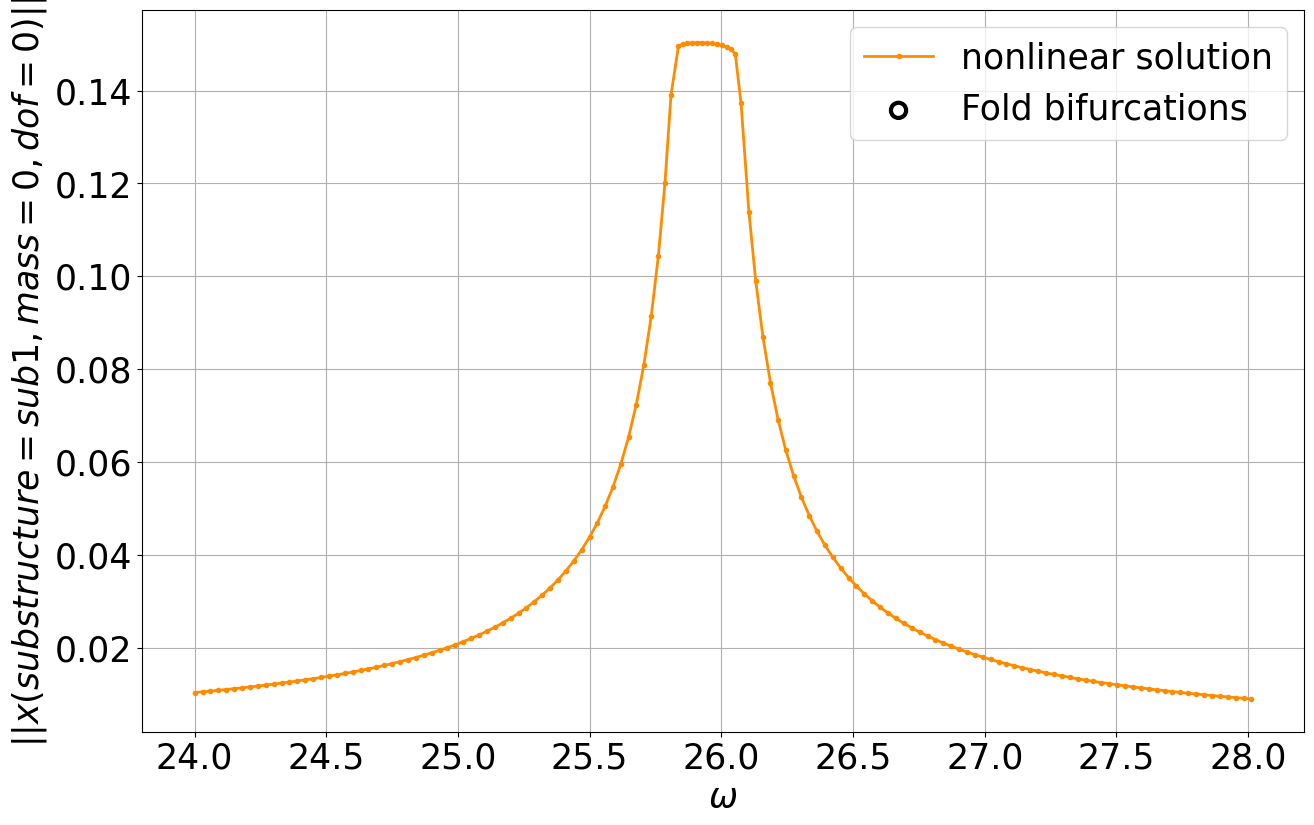

In [8]:
indices_selection = ("sub1", 0, 0)
indexH = NRB_J.getIndex(*indices_selection)
SA = [sol for sol in NRB_J.nls["FRF"].SolList if sol.flag_accepted]
om = np.array([sol.x[-1] for sol in SA])
ampH = np.array([np.linalg.norm(sol.x[indexH]) for sol in SA])

SA_bifurc = [
    sol for sol in NRB_J.nls["FRF"].SolList if (sol.flag_accepted and sol.flag_bifurcation)
]
om_bifurc = np.array([sol.x[-1] for sol in SA_bifurc])
ampH_bifurc = np.array([np.linalg.norm(sol.x[indexH]) for sol in SA_bifurc])

fig, ax = plt.subplots(figsize=ratio_fig)
ax.plot(om, ampH, **style_plots_ref["frf_nl"])
ax.scatter(
    om_bifurc,
    ampH_bifurc,
    s=120,
    marker="o",
    color="k",
    facecolors="none",
    linewidth=3,
    label="Fold bifurcations",
)
ax.set_xlabel("$\\omega$")
ax.set_ylabel("$\|\|x(substructure={},mass={},dof={})\|\|$".format(*indices_selection))
ax.legend()
ax.grid()

# Thrid test case : One Dof Gap

In [9]:
# ------------------ SYSTEM CONSTRUCTION ------------------ #
MassMatrix = np.array([[1]])
DampMatrix = 1e-1 * np.array([[np.sqrt(40)]])
RigidMatrix = np.array([[40]])
LinSys = dict()
LinSys["M"] = MassMatrix
LinSys["C"] = DampMatrix
LinSys["K"] = RigidMatrix
LinSys["G"] = 0 * MassMatrix


# ------------------ INPUT CONSTRUCTION ------------------ #
INP = {
    "analysis": {
        "FRF": {
            "study": "frf",
            "puls_inf": 2.0,
            "puls_sup": 15.0,
            "ds0": 1e-1,
            "ds_min": 1e-12,
            "ds_max": 1e-1,
            "sign_ds": 1,
            "verbose": True,
            "stepsizer": "acceptance",
            "predictor": "tangent",
            "predictor_options": {"verbose": True},
            "corrector": "arc_length",
            "preconditioner": "allgower_xpred",
            "stopper": "bounds",
            "solver": "scipyroot",
        }
    },
    "system": {
        "type": "Base",
        "nh": 7,
        "nti": 1024,
        "adim": {"status": True, "lc": 10.0, "wc": 1.0},
    },
    "substructures": {"sub1": {"matrix": LinSys, "ndofs": 1}},
    "connectors": {
        "loading": {
            "type": "CosinusForcing",
            "connect": {"sub1": [0]},
            "dirs": [0],
            "amp": 1e2,
        },
        "gap": {
            "type": "PenaltyUnilateralGap",
            "connect": {"sub1": [0]},
            "dirs": [0],
            "g": 10,
            "k": 1000.0,
        },
    },
}

# ------------------ PYHARM MAESTRO CONSTRUCTION ------------------ #
NRB_ODG = pyHarm.Maestro(INP)
NRB_ODG.operate()

solution converged at om=2.0
solution converged at om=2.0999477612079738
solution converged at om=2.1998876821983915
solution converged at om=2.299818673592073
solution converged at om=2.3997394746463656
solution converged at om=2.4996486209218727
solution converged at om=2.5995444049624097
solution converged at om=2.6994248282564075
solution converged at om=2.799287542265345
solution converged at om=2.8991297756723924
solution converged at om=2.9989482441712556
solution converged at om=3.098739038011435
solution converged at om=3.1984974810456768
solution converged at om=3.2982179530558455
solution converged at om=3.3978936644811752
solution converged at om=3.4975163690831876
solution converged at om=3.5970759952007616
solution converged at om=3.6965601695866144
solution converged at om=3.795953598696841
solution converged at om=3.8952372598063043
solution converged at om=3.994387337212029
solution converged at om=4.09337381547421
solution converged at om=4.1921586102109885
solution c

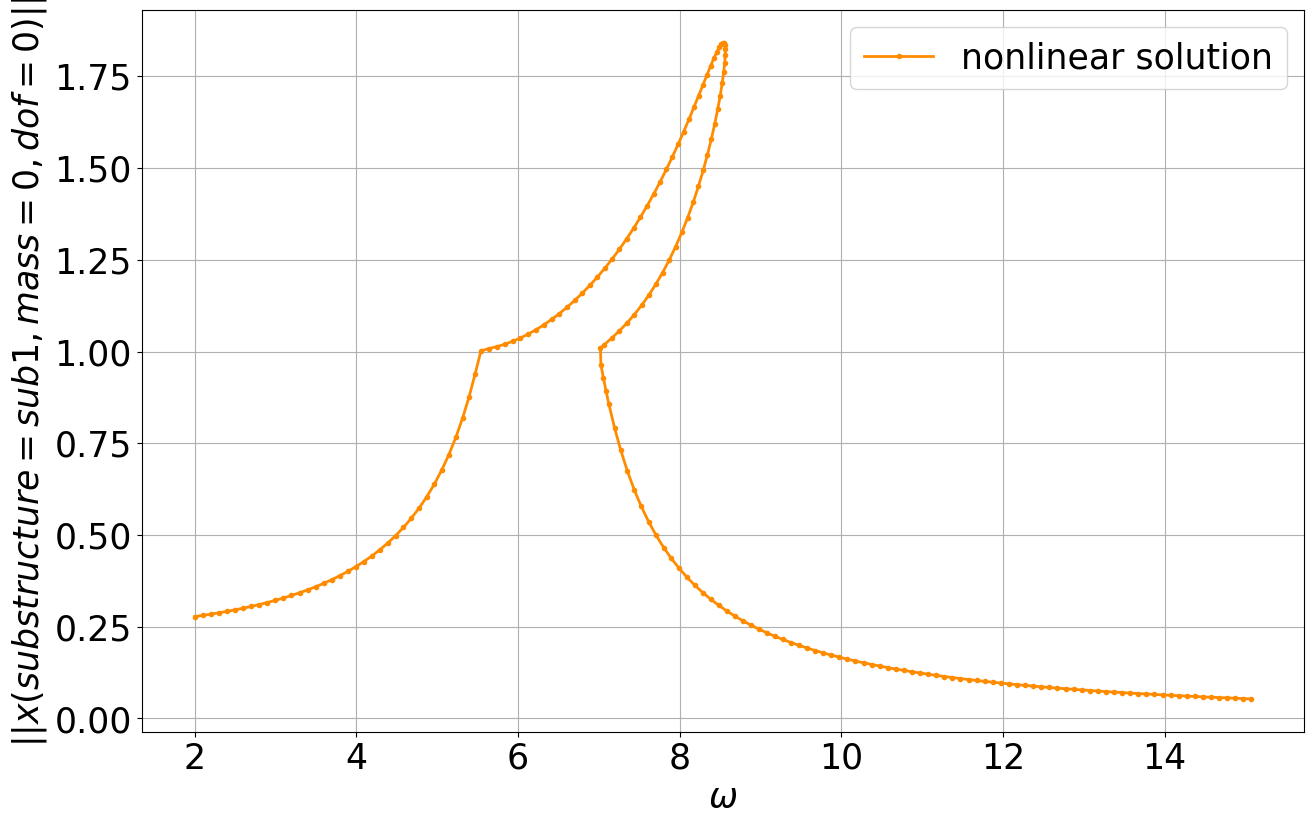

In [10]:
indices_selection = ("sub1", 0, 0)
indexH = NRB_ODG.getIndex(*indices_selection)
SA = [sol for sol in NRB_ODG.nls["FRF"].SolList if sol.flag_accepted]
SA_bifurc = [
    sol for sol in NRB_ODG.nls["FRF"].SolList if (sol.flag_accepted and sol.flag_bifurcation)
]
om = np.array([sol.x[-1] for sol in SA])
ampH = np.array([np.linalg.norm(sol.x[indexH]) for sol in SA])
om_bifurc = np.array([sol.x[-1] for sol in SA_bifurc])
ampH_bifurc = np.array([np.linalg.norm(sol.x[indexH]) for sol in SA_bifurc])

fig, ax = plt.subplots(figsize=ratio_fig)
ax.plot(om, ampH, **style_plots_ref["frf_nl"])
ax.set_xlabel("$\\omega$")
ax.set_ylabel("$\|\|x(substructure={},mass={},dof={})\|\|$".format(*indices_selection))
ax.legend()
ax.grid()

# Fourth test case : Jeffcott rotor type
For this test case the input matrix are given in the file "NRB_yx.mat"

In [12]:
# ------------------ INPUT CONSTRUCTION ------------------ #
INP = {
    "analysis": {
        "FRF": {
            "study": "frf",
            "puls_inf": 6.28,
            "puls_start": 6.28,
            "puls_sup": 60.0,
            "ds0": 1e-1,
            "ds_min": 1e-12,
            "ds_max": 1e-1,
            "sign_ds": 1,
            "verbose": True,
            "stepsizer": "acceptance",
            "predictor": "tangent",
            "corrector": "arc_length",
            "preconditioner": "allgower",
            "stopper": "bounds",
            "solver": "scipyroot",
        }
    },
    "system": {
        "type": "Base",
        "nh": 1,
        "nti": 128,
        "adim": {"status": True, "lc": 3.0e-4, "wc": 1.0},
    },
    "substructures": {"sub1": {"filename": "./NRB_yx.mat", "ndofs": 4}},
    "connectors": {
        "loading_dir0": {
            "type": "GOForcing",
            "connect": {"sub1": [1]},
            "dirs": [0],
            "dto": 2,
            "phi": 0,
            "ho": 1,
            "amp": 0.6,
        },
        "loading_dir1": {
            "type": "GOForcing",
            "connect": {"sub1": [1]},
            "dirs": [1],
            "dto": 2,
            "phi": np.pi / 2.0,
            "ho": 1,
            "amp": 0.6,
        },
        "gap": {
            "type": "PenaltyBilateralGap",
            "connect": {"sub1": [4], "INTERNAL": [5]},
            "dirs": [0, 1],
            "g": 3.0e-4,
            "k": 1.5e9,
        },
    },
}


# ------------------ PYHARM MAESTRO CONSTRUCTION ------------------ #
NRB_XY = pyHarm.Maestro(INP)
NRB_XY.operate()

solution converged at om=6.28
solution converged at om=6.379903606882679
solution converged at om=6.479803278682343
solution converged at om=6.579698889673735
solution converged at om=6.679590310148787
solution converged at om=6.779477406261544
solution converged at om=6.879360039868172
solution converged at om=6.979238068359182
solution converged at om=7.079111344485806
solution converged at om=7.1789797161787785
solution converged at om=7.27884302635886
solution converged at om=7.378701112741059
solution converged at om=7.478553807628894
solution converged at om=7.578400937702327
solution converged at om=7.678242323792979
solution converged at om=7.77807778065485
solution converged at om=7.877907116719136
solution converged at om=7.9777301338457765
solution converged at om=8.077546627056588
solution converged at om=8.177356384262636
solution converged at om=8.277159185978626
solution converged at om=8.376954805021057
solution converged at om=8.476743006198408
solution converged at om

solution converged at om=24.893833113341095
solution converged at om=24.991849820620573
solution converged at om=25.089888117086154
solution converged at om=25.18794724118734
solution converged at om=25.286026451455673
solution converged at om=25.384125025541554
solution converged at om=25.482242259327993
solution converged at om=25.580377466158975
solution converged at om=25.678529976021974
solution converged at om=25.776699134811025
solution converged at om=25.874884303554012
solution converged at om=25.973084857860695
solution converged at om=26.071300187030698
solution converged at om=26.169529693715354
solution converged at om=26.267772793044216
solution converged at om=26.366028912190572
solution converged at om=26.464297489790482
solution converged at om=26.562577975359098
solution converged at om=26.66086982880999
solution converged at om=26.759172519954927
solution converged at om=26.857485528049615
solution converged at om=26.955808341230036
solution converged at om=27.054140

solution converged at om=45.51947906086906
solution converged at om=45.60292764648314
solution converged at om=45.6860812961509
solution converged at om=45.7689359152782
solution converged at om=45.85148741817791
solution converged at om=45.93373173075919
solution converged at om=46.01566479378534
solution converged at om=46.09728256573734
solution converged at om=46.17858102611193
solution converged at om=46.259556178166285
solution converged at om=46.340204052669776
solution converged at om=46.42052071052012
solution converged at om=46.50050224641213
solution converged at om=46.58014479175777
solution converged at om=46.65944451825497
solution converged at om=46.73839764087773
solution converged at om=46.817000421300484
solution converged at om=46.89524917098358
solution converged at om=46.97314025465962
solution converged at om=47.050670093275265
solution converged at om=47.12783516735334
solution converged at om=47.204632020093726
solution converged at om=47.281057260320786
solutio

solution converged at om=55.277028670727624
solution converged at om=55.296667304409574
solution converged at om=55.31617614024015
solution converged at om=55.33555625940936
solution converged at om=55.35480872999498
solution converged at om=55.37393460691199
solution converged at om=55.39293493252467
solution converged at om=55.411810736470684
solution converged at om=55.430563035737975
solution converged at om=55.44919283553448
solution converged at om=55.4677011276416
solution converged at om=55.48608889284275
solution converged at om=55.504357099090164
solution converged at om=55.52250670329621
solution converged at om=55.54053864985554
solution converged at om=55.55845387213401
solution converged at om=55.576253291635595
solution converged at om=55.593937818856666
solution converged at om=55.61150835259275
solution converged at om=55.62896578098063
solution converged at om=55.64631098121296
solution converged at om=55.663544818955835
solution converged at om=55.68066814996804
solu

solution converged at om=57.496364228954064
solution converged at om=57.49915763941218
solution converged at om=57.50187521125876
solution converged at om=57.504516465963015
solution converged at om=57.50708091422834
solution converged at om=57.50956805555868
solution converged at om=57.51197737810983
solution converged at om=57.51430835876691
solution converged at om=57.51656046226826
solution converged at om=57.518733142170355
solution converged at om=57.520825839097895
solution converged at om=57.52283798222822
solution converged at om=57.524768987643554
solution converged at om=57.52661825930365
solution converged at om=57.528385187487025
solution converged at om=57.53006915015337
solution converged at om=57.531669511316295
solution converged at om=57.53318562158544
solution converged at om=57.53461681772219
solution converged at om=57.53596242234712
solution converged at om=57.53722174364481
solution converged at om=57.538394075505146
solution converged at om=57.53947869661394
sol

solution converged at om=53.19306382327151
solution converged at om=53.11714554897957
solution converged at om=53.040561821973185
solution converged at om=52.96332633805565
solution converged at om=52.885452964838834
solution converged at om=52.80695570586676
solution converged at om=52.72784866534876
solution converged at om=52.648146014521366
solution converged at om=52.567861958753106
solution converged at om=52.487010706574566
solution converged at om=52.40560643994766
solution converged at om=52.32366328616546
solution converged at om=52.24119529155966
solution converged at om=52.158216397060556
solution converged at om=52.07474041521783
solution converged at om=51.99078100930305
solution converged at om=51.90635167417701
solution converged at om=51.821465718663426
solution converged at om=51.736136250103854
solution converged at om=51.650376160241834
solution converged at om=51.564198112989075
solution converged at om=51.47761453366863
solution converged at om=51.39063759970386
s

solution converged at om=33.126390529073426
solution converged at om=33.02718843062239
solution converged at om=32.927987429556524
solution converged at om=32.82878766204338
solution converged at om=32.72958926479347
solution converged at om=32.63039237516422
solution converged at om=32.53111687040002
Alerte: un point limite (fold) a été détecté --> changement de sens de parcours
solution converged at om=32.62432170379489
solution converged at om=32.71721412439216
solution converged at om=32.81038014589677
solution converged at om=32.90380907470173
solution converged at om=32.99749057006732
solution converged at om=33.09141464377198
solution converged at om=33.185571654645486
solution converged at om=33.279952305654895
solution converged at om=33.37454763548335
solution converged at om=33.46934901370521
solution converged at om=33.564348133446224
solution converged at om=33.6595370035919
solution converged at om=33.75490794093798
solution converged at om=33.850453561865706
solution con

solution converged at om=49.27052670412051
solution converged at om=49.37043334733862
solution converged at om=49.47034080278953
solution converged at om=49.57024904430275
solution converged at om=49.67015804640523
solution converged at om=49.77006778430229
solution converged at om=49.86997823385862
solution converged at om=49.969889371577665
solution converged at om=50.06980117458524
solution converged at om=50.16971362061115
solution converged at om=50.26962668797116
solution converged at om=50.36954035699805
solution converged at om=50.4694546042392
solution converged at om=50.56936941111935
solution converged at om=50.66928475814077
solution converged at om=50.769200626314124
solution converged at om=50.869116997143905
solution converged at om=50.96903385261642
solution converged at om=51.0689511751845
solution converged at om=51.16886894775564
solution converged at om=51.26878715367984
solution converged at om=51.368705776736185
solution converged at om=51.46862480112249
solution 

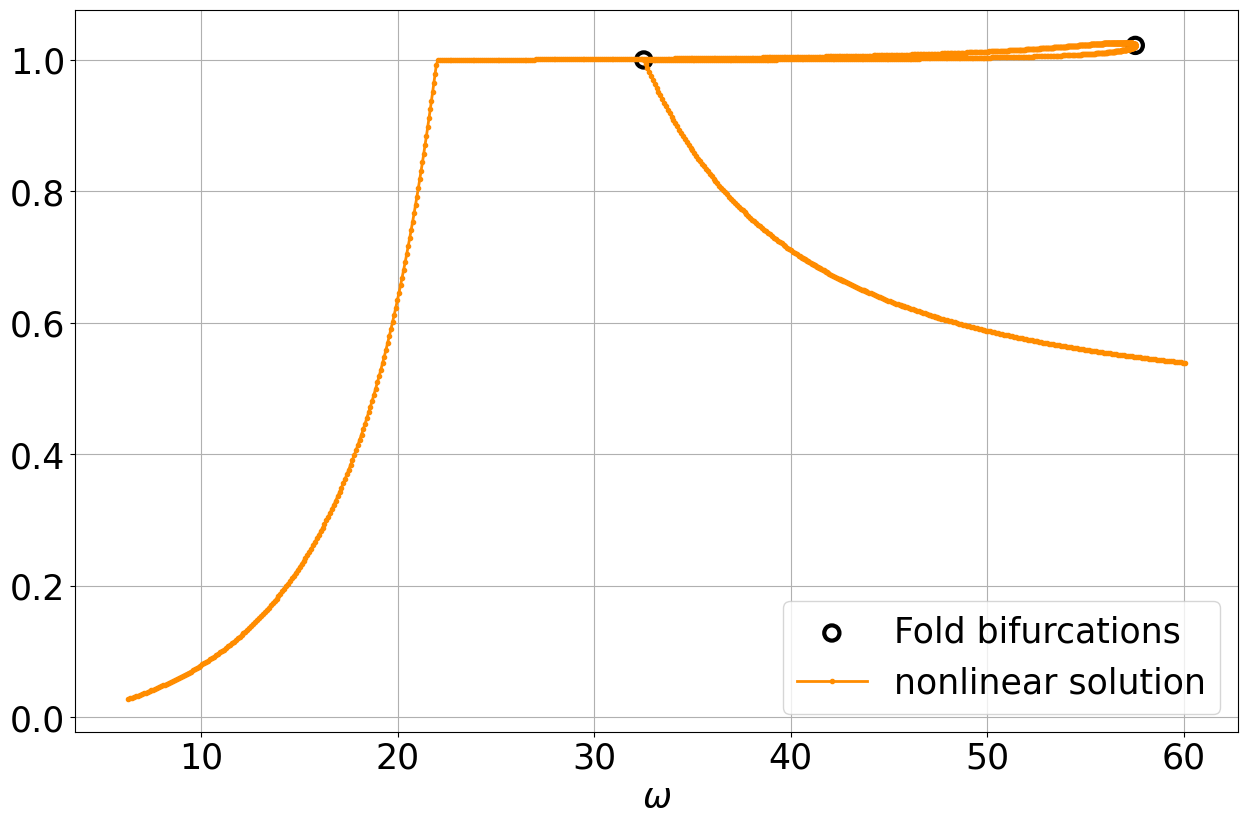

In [13]:
indices_selection_51 = ("sub1", 4, 0)
indices_selection_52 = ("sub1", 4, 1)
indices_selection_61 = ("sub1", 5, 0)
indices_selection_62 = ("sub1", 5, 1)
indexH_51 = NRB_XY.getIndex(*indices_selection_51)
indexH_52 = NRB_XY.getIndex(*indices_selection_52)
indexH_61 = NRB_XY.getIndex(*indices_selection_61)
indexH_62 = NRB_XY.getIndex(*indices_selection_62)

SA = [sol for sol in NRB_XY.nls["FRF"].SolList if sol.flag_accepted]
om = np.array([sol.x[-1] for sol in SA])

from pyHarm.DynamicOperator import compute_DFT

DFTO = compute_DFT(NRB_XY.system.nti, NRB_XY.system.nh)
ampH = np.array(
    [
        np.linalg.norm(
            (
                np.sqrt(
                    ((sol.x[indexH_51] - sol.x[indexH_61]) @ DFTO["ft"]) ** 2
                    + ((sol.x[indexH_52] - sol.x[indexH_62]) @ DFTO["ft"]) ** 2
                )
            )
            @ DFTO["tf"]
        )
        for sol in SA
    ]
)


SA_bifurc = [
    sol for sol in NRB_XY.nls["FRF"].SolList if (sol.flag_accepted and sol.flag_bifurcation)
]
om_bifurc = np.array([sol.x[-1] for sol in SA_bifurc])
ampH_bifurc = np.array(
    [
        np.linalg.norm(
            (
                np.sqrt(
                    ((sol.x[indexH_51] - sol.x[indexH_61]) @ DFTO["ft"]) ** 2
                    + ((sol.x[indexH_52] - sol.x[indexH_62]) @ DFTO["ft"]) ** 2
                )
            )
            @ DFTO["tf"]
        )
        for sol in SA_bifurc
    ]
)


fig, ax = plt.subplots(figsize=ratio_fig)
ax.scatter(
    om_bifurc,
    ampH_bifurc,
    s=120,
    marker="o",
    color="k",
    facecolors="none",
    linewidth=3,
    label="Fold bifurcations",
)
ax.plot(om, ampH, **style_plots_ref["frf_nl"])
ax.set_xlabel("$\\omega$")
# ax.set_ylabel("$\|\|x(substructure={},mass={},dof={})\|\|$".format(*indices_selection))
ax.legend()
ax.grid()